In [1]:
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt

In [2]:
img_gray = Image.open("C:/Users/PC-LAB1/img_processing_lab/images/Original_lena512.jpg")
image_gray = np.array(img_gray)

img_rgb = Image.open("C:/Users/PC-LAB1/img_processing_lab/images/lena5.jpg")
image_rgb = np.array(img_rgb)

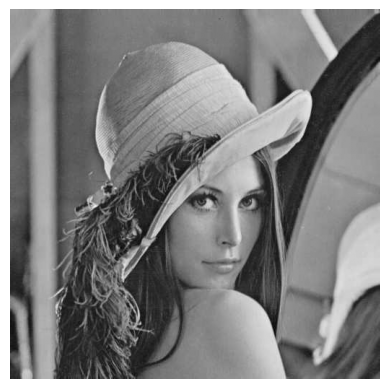

In [3]:
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()

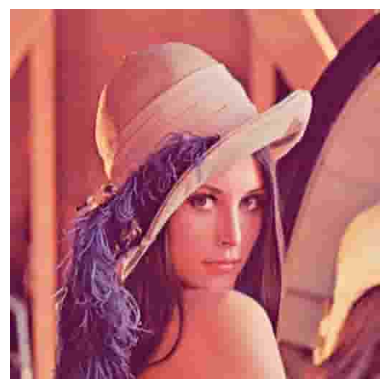

In [4]:
plt.imshow(image_rgb, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
print("Shape:", image_gray.shape)
print("Data type:", image_gray.dtype)
print("Minimum:", image_gray.min())
print("Maximum:", image_gray.max())
print("Mean:", image_gray.mean())


Shape: (512, 512)
Data type: uint8
Minimum: 10
Maximum: 255
Mean: 124.06368255615234


In [6]:
print("Shape:", image_rgb.shape)
print("Data type:", image_rgb.dtype)
print("Minimum:", image_rgb.min())
print("Maximum:", image_rgb.max())
print("Mean:", image_rgb.mean())

Shape: (512, 512, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 128.09458033243814


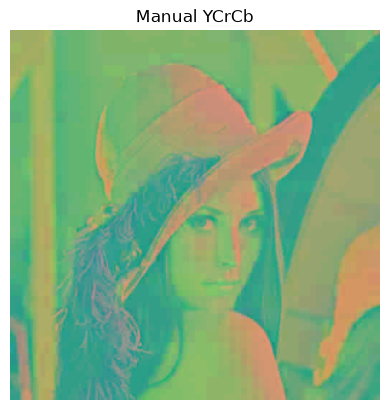

Shape: (512, 512, 3)
Data type: uint8
Minimum: 10
Maximum: 248
Mean: 135.87810134887695


In [7]:
# Extract and cast color channels to float
R = image_rgb[:, :, 0].astype(np.float32)
G = image_rgb[:, :, 1].astype(np.float32)
B = image_rgb[:, :, 2].astype(np.float32)

# Apply conversion equations
Y  =  0.29900 * R + 0.58700 * G + 0.11400 * B
Cr = (0.50000 * R - 0.41869 * G - 0.08131 * B) + 128
Cb = (-0.16874 * R - 0.33126 * G + 0.50000 * B) + 128

# Stack channels and clip values to valid [0, 255] range
image_ycrcb = np.clip(np.stack([Y, Cr, Cb], axis=-1), 0, 255).astype(np.uint8)

plt.imshow(image_ycrcb)
plt.title("Manual YCrCb")
plt.axis("off")
plt.show()

print("Shape:", image_ycrcb.shape)
print("Data type:", image_ycrcb.dtype)
print("Minimum:", image_ycrcb.min())
print("Maximum:", image_ycrcb.max())
print("Mean:", image_ycrcb.mean())

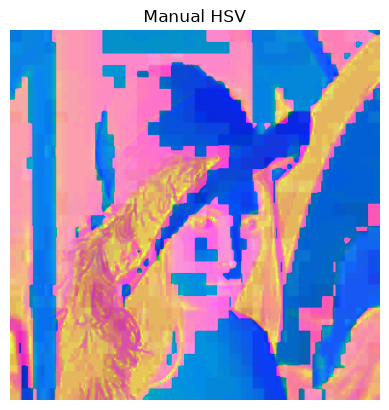

Shape: (512, 512, 3)
Data type: float32
Minimum: 0.0
Maximum: 1.0
Mean: 0.5898079


In [ ]:
# Normalize RGB values to [0, 1]
rgb_norm = image_rgb.astype(np.float32) / 255.0
r, g, b = rgb_norm[..., 0], rgb_norm[..., 1], rgb_norm[..., 2]

cmax = np.max(rgb_norm, axis=-1)
cmin = np.min(rgb_norm, axis=-1)
diff = cmax - cmin

# Initialize arrays
h = np.zeros_like(cmax)
s = np.zeros_like(cmax)
v = cmax

# Calculate Saturation
s[cmax != 0] = diff[cmax != 0] / cmax[cmax != 0]

# Calculate Hue for each case
idx_r = (cmax == r) & (diff != 0)
h[idx_r] = (60 * ((g[idx_r] - b[idx_r]) / diff[idx_r]) + 360) % 360

idx_g = (cmax == g) & (diff != 0)
h[idx_g] = (60 * ((b[idx_g] - r[idx_g]) / diff[idx_g]) + 120) % 360

idx_b = (cmax == b) & (diff != 0)
h[idx_b] = (60 * ((r[idx_b] - g[idx_b]) / diff[idx_b]) + 240) % 360

# Prepare normalized HSV image for Matplotlib ([0, 1] range)
image_hsv_disp = np.stack([h / 360.0, s, v], axis=-1)

plt.imshow(image_hsv_disp)
plt.title("Manual HSV")
plt.axis("off")
plt.show()

print("Shape:", image_hsv_disp.shape)
print("Data type:", image_hsv_disp.dtype)
print("Minimum:", image_hsv_disp.min())
print("Maximum:", image_hsv_disp.max())
print("Mean:", image_hsv_disp.mean())

In [11]:
# Initialize a single row array with 256 columns of zeros
histogram = np.zeros((1, 256), dtype=int)

# Get the height and width of the image
height, width = image_gray.shape

# Loop through every row (y) and column (x)
for y in range(height):
  for x in range(width):
    histogram[0, image_gray[y, x]] += 1  # Increment the count for that value

In [10]:
hist = np.bincount(image_gray.ravel(), minlength=256).reshape(1, -1)
hist

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    1,
           2,    1,    1,    1,    4,    3,    2,    2,    9,    6,   11,
          19,   28,   29,   34,   45,   72,   74,   91,  118,  204,  200,
         249,  316,  403,  507,  590,  634,  778,  960, 1146, 1290, 1451,
        1633, 1878, 1938, 2029, 2068, 2034, 2124, 2167, 1936, 1837, 1774,
        1680, 1577, 1494, 1380, 1292, 1179, 1055, 1009,  929,  915,  842,
         800,  819,  820,  771,  785,  826,  835,  877,  865,  910,  961,
         902,  974,  938,  942,  840,  878,  956,  903,  966,  939, 1018,
        1068, 1024, 1165, 1164, 1226, 1277, 1324, 1446, 1594, 1915, 2206,
        1957, 2397, 1869, 1979, 1862, 1919, 1652, 1519, 1413, 1445, 1289,
        1411, 1306, 1293, 1361, 1368, 1376, 1372, 1454, 1538, 1551, 1465,
        1795, 1623, 1821, 1759, 2195, 2774, 2175, 2718, 2390, 2749, 2070,
        2364, 1930, 1773, 1921, 1826, 1953, 1993, 2211, 2354, 2117, 2512,
        2288, 2523, 2252, 2544, 2412, 

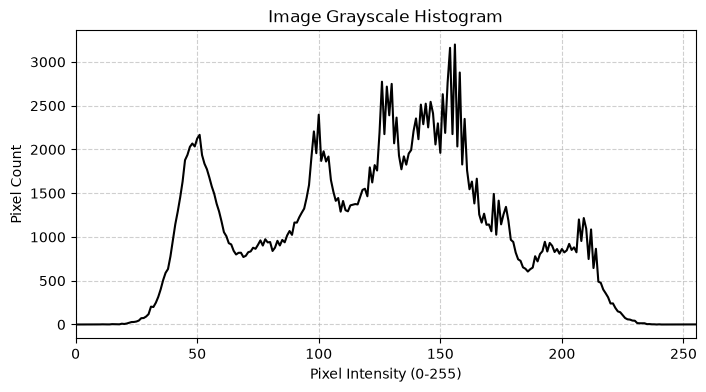

In [12]:
# Plot the histogram values as a line or bar chart
plt.figure(figsize=(8, 4))
plt.plot(hist[0], color="black")
plt.title("Image Grayscale Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Pixel Count")
plt.xlim([0, 255])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

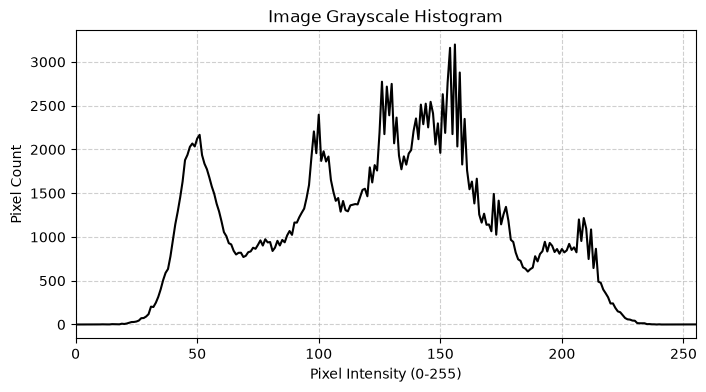

In [13]:
# Plot the histogram values as a line or bar chart
plt.figure(figsize=(8, 4))
plt.plot(histogram[0], color="black")
plt.title("Image Grayscale Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Pixel Count")
plt.xlim([0, 255])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

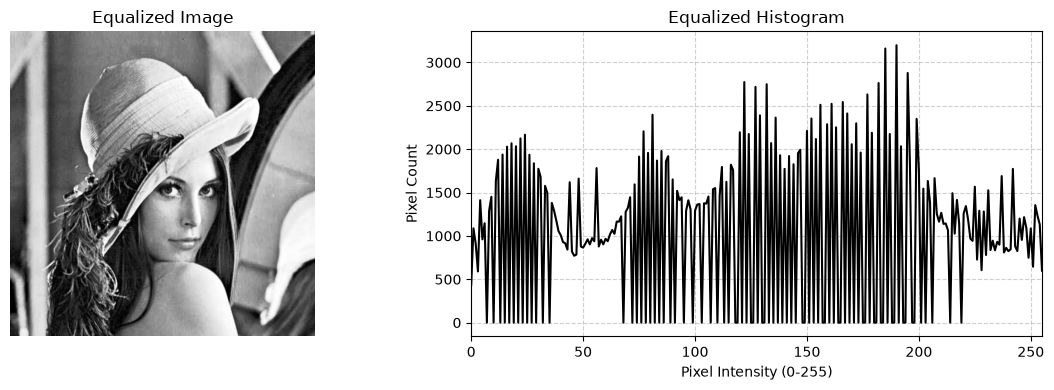

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute the histogram of the grayscale image
hist, _ = np.histogram(image_gray.flatten(), bins=256, range=[0, 256])

# 2. Compute the Cumulative Distribution Function (CDF)
cdf = hist.cumsum()

# 3. Normalize the CDF to the [0, 255] range
cdf_min = cdf[cdf > 0].min()  # Find the first non-zero minimum value in CDF
total_pixels = image_gray.size
cdf_normalized = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255).astype(np.uint8)

# 4. Map the original pixel values to the new equalized values (using CDF as a lookup table)
image_equalized = cdf_normalized[image_gray]

# 5. Compute the new histogram for the equalized image
hist_equalized, _ = np.histogram(image_equalized.flatten(), bins=256, range=[0, 256])

# 6. Plot the equalized image and its histogram side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot Equalized Image
axes[0].imshow(image_equalized, cmap="gray")
axes[0].set_title("Equalized Image")
axes[0].axis("off")

# Plot Equalized Histogram
axes[1].plot(hist_equalized, color="black")
axes[1].set_title("Equalized Histogram")
axes[1].set_xlabel("Pixel Intensity (0-255)")
axes[1].set_ylabel("Pixel Count")
axes[1].set_xlim([0, 255])
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

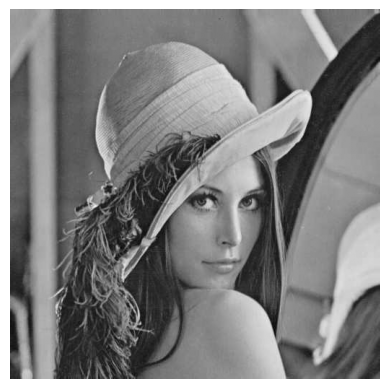

In [15]:
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()